<a href="https://colab.research.google.com/github/matheusacsoares/checkpoint02-energia-renovavel-ml/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## Integrantes

- Lucas Bellezzo Figueiredo – RM569734
- Maria Luiza Vieira de Freitas – RM571535
- Giovanna Ferreira Almeida – RM571822
- Matheus Arruda Camara Soares – RM571594
- Matheus Sabino da Silva Guedes – RM572907

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas


EOL: 1200 linhas recebidas


UHE: 221 linhas recebidas


PCH: 537 linhas recebidas


CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Imports que adicionamos além dos que já estavam acima
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

## Tarefa 1 – Análise exploratória

Usamos o CSV gerado pela consulta acima. Se a API não responder, dá para usar a linha comentada na célula anterior, que lê o CSV do repositório do professor.

In [9]:
dados = pd.read_csv("aneel_classificacao_orange.csv")

print("Linhas e colunas:", dados.shape)
print()
print(dados.dtypes)
print()
print("Valores ausentes:")
print(dados.isnull().sum())
dados.head()

Linhas e colunas: (3876, 4)

potencia_kw    float64
latitude       float64
longitude      float64
fonte              str
dtype: object

Valores ausentes:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


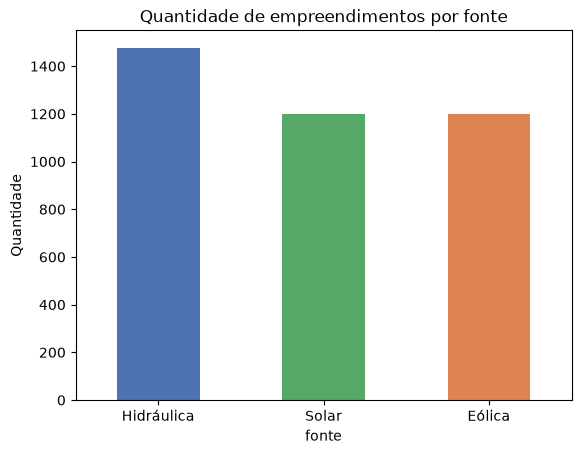

In [10]:
print(dados["fonte"].value_counts())

dados["fonte"].value_counts().plot(kind="bar", color=["#4C72B0", "#55A868", "#DD8452"])
plt.title("Quantidade de empreendimentos por fonte")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

In [11]:
# Potência por fonte
dados.groupby("fonte")["potencia_kw"].describe()

,count,mean,std,min,25%,50%,75%,max
fonte,,,,,,,,
Eólica,1200.0,30748.353217,13785.299021,0.16,23100.0,29600.0,37200.0,105000.0
Hidráulica,1476.0,75809.158279,486419.578953,0.99,990.0,4000.0,17000.0,11233100.0
Solar,1200.0,10812.736733,17664.656938,0.26,1.0,1.0,27000.0,137480.0


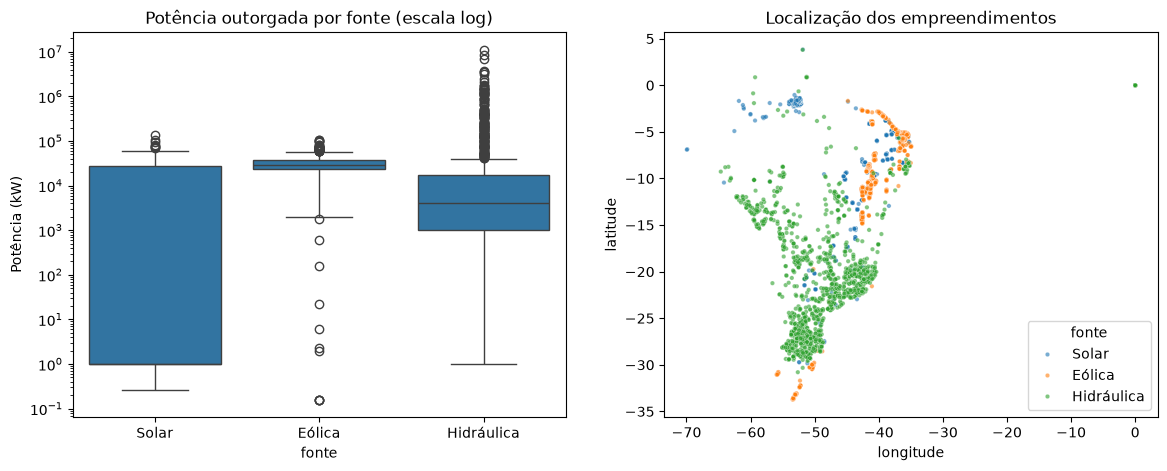

Usinas solares com potência = 1 kW: 772


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# potência tem valores muito diferentes (de 1 kW até milhões), então usamos escala log
sns.boxplot(data=dados, x="fonte", y="potencia_kw", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Potência outorgada por fonte (escala log)")
axes[0].set_ylabel("Potência (kW)")

sns.scatterplot(data=dados, x="longitude", y="latitude", hue="fonte", s=10, alpha=0.6, ax=axes[1])
axes[1].set_title("Localização dos empreendimentos")
plt.show()

print("Usinas solares com potência = 1 kW:", (dados[dados["fonte"] == "Solar"]["potencia_kw"] == 1).sum())

### O que observamos

- São 3876 empreendimentos e não tem nenhum valor ausente (o código do professor já descartava linhas sem potência ou coordenada).
- As classes ficaram parecidas em tamanho: Hidráulica tem 1476 (soma de UHE, PCH e CGH) e Solar e Eólica têm 1200 cada. Esse 1200 é o `limit` da consulta, então **não é a proporção real** de usinas no Brasil, é só o que a API devolveu.
- A potência varia muito. As eólicas ficam quase todas na faixa de 10 a 40 mil kW, as hidráulicas vão de usinas bem pequenas até mais de 11 milhões de kW, e as solares têm um valor estranho: **772 das 1200 têm potência de exatamente 1 kW**. Parece mais um valor de cadastro do que a potência real.
- No mapa dá para ver que cada fonte se concentra em uma região: eólicas no Nordeste, hidráulicas no Sul/Sudeste e muitas solares no Norte. Isso deve ajudar bastante os modelos.

## Tarefa 1 – Definição de X e y e divisão treino/teste

- `X`: `potencia_kw`, `latitude` e `longitude`
- `y`: `fonte` (Solar, Eólica ou Hidráulica)

A divisão é 80% treino e 20% teste, **estratificada** pela fonte (para as três classes aparecerem na mesma proporção nos dois conjuntos) e com `random_state=42`.

In [13]:
X = dados[["potencia_kw", "latitude", "longitude"]]
y = dados["fonte"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Treino:", X_treino.shape[0], "linhas")
print("Teste:", X_teste.shape[0], "linhas")
print()
print("Proporção das classes no treino:")
print(y_treino.value_counts(normalize=True).round(3))
print()
print("Proporção das classes no teste:")
print(y_teste.value_counts(normalize=True).round(3))

Treino: 3100 linhas
Teste: 776 linhas

Proporção das classes no treino:
fonte
Hidráulica    0.381
Solar         0.310
Eólica        0.310
Name: proportion, dtype: float64

Proporção das classes no teste:
fonte
Hidráulica    0.381
Solar         0.309
Eólica        0.309
Name: proportion, dtype: float64


## Tarefa 1 – Modelos

Escolhemos os três classificadores que já estavam importados:

1. **KNN**: classifica olhando os vizinhos mais próximos. Como usa distância, precisa padronizar os dados, senão a potência (que vai até milhões) domina a latitude e a longitude.
2. **Regressão Logística**: modelo linear, o mesmo da Aula 06. Também padronizamos.
3. **Random Forest**: conjunto de árvores de decisão. Não precisa de padronização.

Para a padronização ser feita só com os dados de treino, colocamos o `StandardScaler` dentro de um `make_pipeline`. Assim o `fit` aprende a média e o desvio só no treino e depois só aplica no teste.

Como são 3 classes, usamos **média `macro`** em Precision, Recall e F1 (calcula a métrica para cada classe e tira a média simples, sem dar peso maior para a classe com mais exemplos).

In [14]:
modelos_classificacao = {
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random Forest": RandomForestClassifier(random_state=42),
}

resultados_classificacao = []
previsoes_classificacao = {}

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino, y_treino)
    y_prev = modelo.predict(X_teste)
    previsoes_classificacao[nome] = y_prev

    resultados_classificacao.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, y_prev),
        "Precision (macro)": precision_score(y_teste, y_prev, average="macro"),
        "Recall (macro)": recall_score(y_teste, y_prev, average="macro"),
        "F1 (macro)": f1_score(y_teste, y_prev, average="macro"),
    })

tabela_classificacao = pd.DataFrame(resultados_classificacao)
print("Divisão: 80/20 estratificada, random_state=42 | média das métricas: macro")
tabela_classificacao.round(4)

Divisão: 80/20 estratificada, random_state=42 | média das métricas: macro


,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,KNN,0.9665,0.9677,0.9649,0.9662
1,Regressão Logística,0.8235,0.8275,0.8200,0.8182
2,Random Forest,0.9755,0.9769,0.9741,0.9753


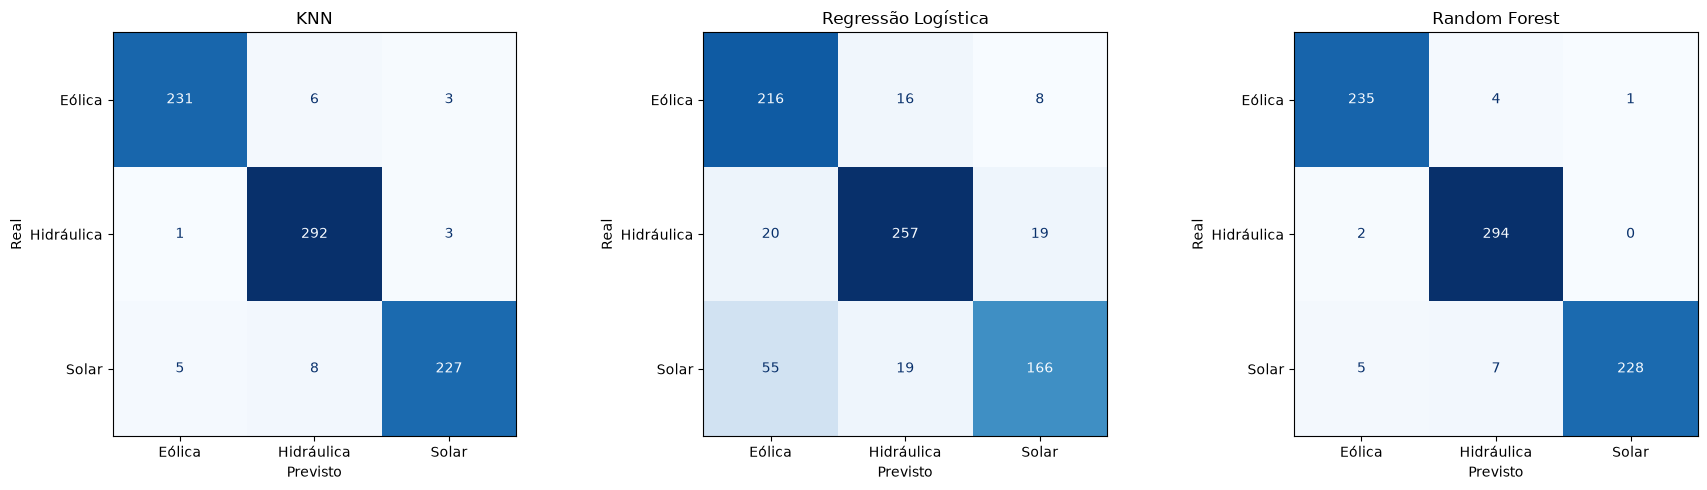

In [15]:
classes = ["Eólica", "Hidráulica", "Solar"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, y_prev) in zip(axes, previsoes_classificacao.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_teste, y_prev, labels=classes), display_labels=classes).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

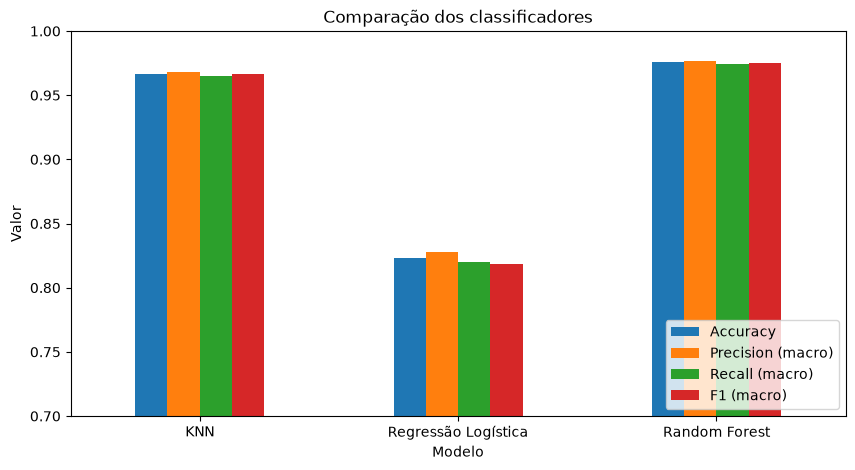

In [16]:
tabela_classificacao.set_index("Modelo").plot(kind="bar", figsize=(10, 5))
plt.title("Comparação dos classificadores")
plt.ylabel("Valor")
plt.ylim(0.7, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

### Interpretação – Tarefa 1

**Resultados:** o Random Forest foi o melhor nas quatro métricas (accuracy de 0,976 e F1 macro de 0,975), com o KNN bem perto (0,966 nas duas). A Regressão Logística ficou bem abaixo (accuracy de 0,823 e F1 de 0,818).

**Por que a Regressão Logística foi pior:** ela separa as classes com fronteiras retas. Aqui as fontes estão em "regiões" do mapa e em faixas de potência que não se separam bem por uma reta. O KNN e o Random Forest conseguem fazer fronteiras mais irregulares.

**Classes mais confundidas:** na Regressão Logística o maior erro é Solar sendo prevista como Eólica (55 casos), já que as duas aparecem muito no Nordeste. No Random Forest e no KNN quase todos os erros também envolvem Solar, principalmente Solar prevista como Hidráulica ou como Eólica.

**Modelo escolhido:** Random Forest, por ter os maiores valores em todas as métricas e não precisar de padronização.

**Limitações:** o resultado alto não quer dizer que dá para descobrir a fonte de qualquer usina só por potência e localização:
- A amostra não é aleatória. A API devolveu as primeiras 1200 linhas de cada tipo, e elas parecem concentradas em algumas regiões (muitas solares no Norte, por exemplo). Com o cadastro completo, as regiões das fontes se misturam mais e o modelo provavelmente erraria mais.
- Muitas solares têm potência de 1 kW, um valor que parece de cadastro. O modelo pode estar aprendendo esse detalhe e não uma característica real das usinas solares.
- Potência outorgada não é energia gerada, e o cadastro tem usinas em fases diferentes (operando, em construção etc.).
- Numa aplicação real seria preciso usar outras informações (clima da região, relevo, rios próximos, fase do empreendimento) e testar com dados mais representativos.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [17]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [18]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [19]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [20]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## Tarefa 2 – Análise exploratória

In [21]:
meteo = pd.read_csv("meteo_regressao_orange.csv")
meteo = meteo.sort_values("data_hora").reset_index(drop=True)

print("Linhas e colunas:", meteo.shape)
print("Período:", meteo["data_hora"].iloc[0], "até", meteo["data_hora"].iloc[-1])
print()
print("Valores ausentes:")
print(meteo.isnull().sum())
meteo.head()

Linhas e colunas: (1001, 7)
Período: 2025-04-01T07:00 até 2025-06-30T17:00

Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


In [22]:
meteo.describe()

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


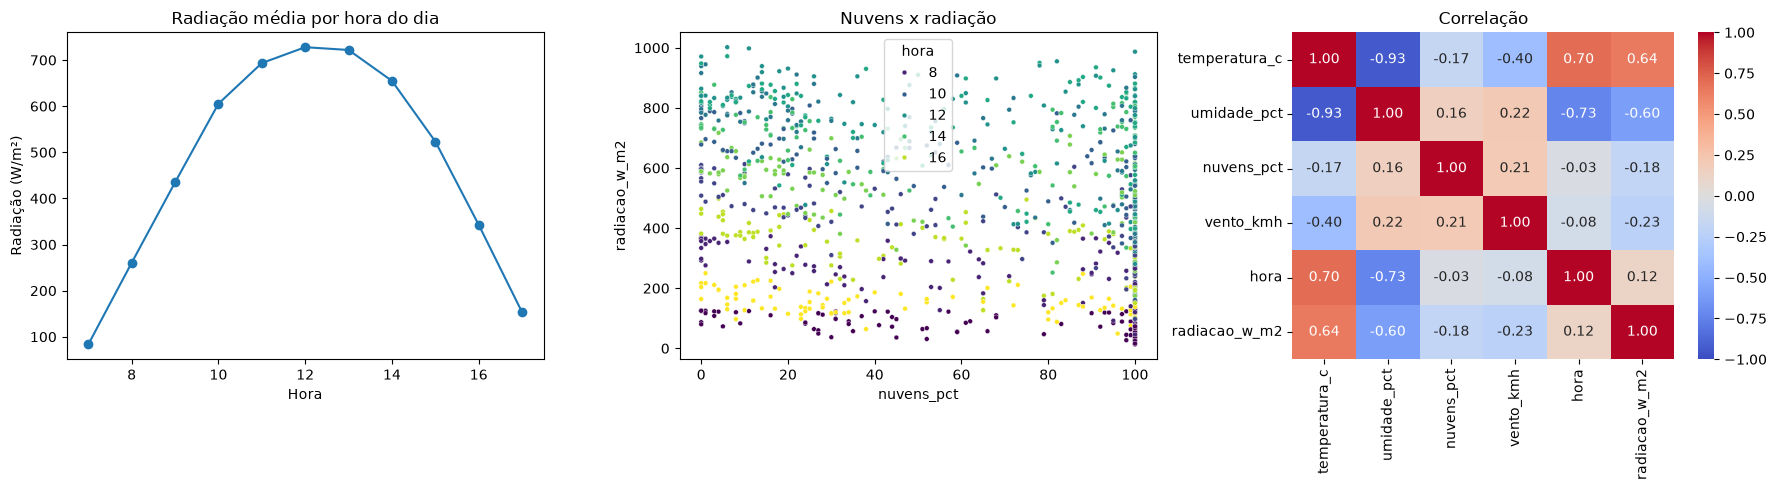

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

meteo.groupby("hora")["radiacao_w_m2"].mean().plot(marker="o", ax=axes[0])
axes[0].set_title("Radiação média por hora do dia")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Radiação (W/m²)")

sns.scatterplot(data=meteo, x="nuvens_pct", y="radiacao_w_m2", hue="hora", palette="viridis", s=12, ax=axes[1])
axes[1].set_title("Nuvens x radiação")

sns.heatmap(meteo.drop(columns="data_hora").corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title("Correlação")

plt.tight_layout()
plt.show()

### O que observamos

- São 1001 horas (91 dias × 11 horas, das 7h às 17h), sem valores ausentes.
- A radiação vai de quase zero até cerca de 1000 W/m², com média de 473 W/m².
- O gráfico por hora tem formato de "sino": começa baixo às 7h, chega no máximo por volta de 12h–13h e cai de novo até as 17h. Por isso a correlação da `hora` com a radiação é só 0,12, mesmo a hora sendo muito importante: a relação não é uma reta, ela sobe e depois desce.
- A temperatura tem correlação positiva (0,64) e a umidade negativa (−0,60). Faz sentido, porque com mais sol esquenta e a umidade relativa cai.
- As nuvens têm correlação negativa, mas mais fraca do que esperávamos (−0,18). No gráfico, mesmo com 100% de nuvens ainda aparecem horas com radiação alta.

## Tarefa 2 – Definição de X e y e divisão temporal

- `X`: `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh` e `hora`
- `y`: `radiacao_w_m2`

`data_hora` não entra no modelo, só serve para ordenar. Como são dados no tempo, **não embaralhamos**: as primeiras 80% das horas vão para treino e as últimas 20% para teste. Assim o modelo é testado em dias "do futuro", que ele não viu.

In [24]:
X_r = meteo[["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]]
y_r = meteo["radiacao_w_m2"]

corte = int(len(meteo) * 0.8)
X_r_treino, X_r_teste = X_r.iloc[:corte], X_r.iloc[corte:]
y_r_treino, y_r_teste = y_r.iloc[:corte], y_r.iloc[corte:]

print("Treino:", len(X_r_treino), "horas, de", meteo["data_hora"].iloc[0], "até", meteo["data_hora"].iloc[corte - 1])
print("Teste:", len(X_r_teste), "horas, de", meteo["data_hora"].iloc[corte], "até", meteo["data_hora"].iloc[-1])

Treino: 800 horas, de 2025-04-01T07:00 até 2025-06-12T14:00
Teste: 201 horas, de 2025-06-12T15:00 até 2025-06-30T17:00


## Tarefa 2 – Modelos

1. **Regressão Linear**: o modelo mais simples, já usado na Aula 07. Serve de base de comparação.
2. **Árvore de Decisão**: consegue capturar relações que não são retas, como a da hora. Limitamos a profundidade em 5 (`max_depth=5`) para ela não decorar o treino.
3. **Random Forest**: várias árvores juntas, que costuma errar menos que uma árvore só.

Nenhum dos três precisa de padronização para funcionar, então usamos os dados como estão.

In [25]:
modelos_regressao = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
}

resultados_regressao = []
previsoes_regressao = {}

for nome, modelo in modelos_regressao.items():
    modelo.fit(X_r_treino, y_r_treino)
    y_prev = modelo.predict(X_r_teste)
    previsoes_regressao[nome] = y_prev

    resultados_regressao.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y_r_teste, y_prev),
        "MSE ((W/m²)²)": mean_squared_error(y_r_teste, y_prev),
        "R²": r2_score(y_r_teste, y_prev),
    })

tabela_regressao = pd.DataFrame(resultados_regressao)
print("Divisão: primeiras 80% das horas para treino, últimas 20% para teste (sem embaralhar)")
tabela_regressao.round(3)

Divisão: primeiras 80% das horas para treino, últimas 20% para teste (sem embaralhar)


,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.205,30034.201,0.360
1,Árvore de Decisão,90.395,14478.577,0.691
2,Random Forest,66.804,7307.418,0.844


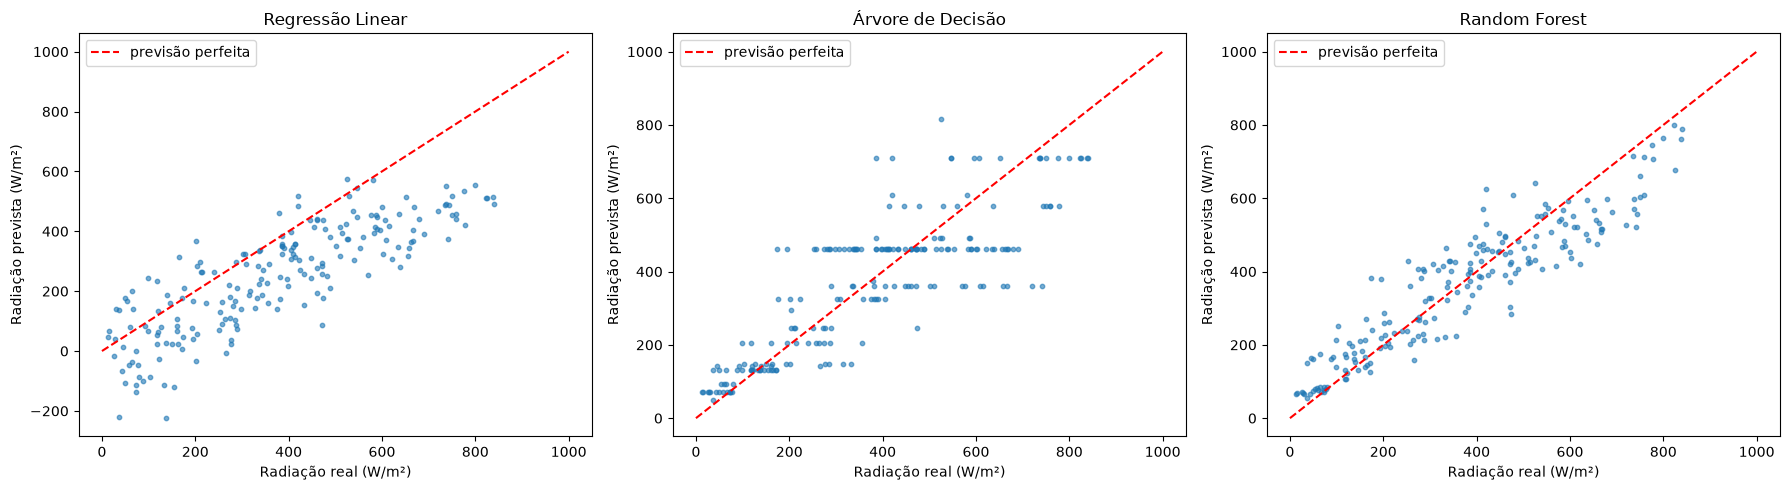

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, y_prev) in zip(axes, previsoes_regressao.items()):
    ax.scatter(y_r_teste, y_prev, s=10, alpha=0.6)
    ax.plot([0, 1000], [0, 1000], color="red", linestyle="--", label="previsão perfeita")
    ax.set_title(nome)
    ax.set_xlabel("Radiação real (W/m²)")
    ax.set_ylabel("Radiação prevista (W/m²)")
    ax.legend()
plt.tight_layout()
plt.show()

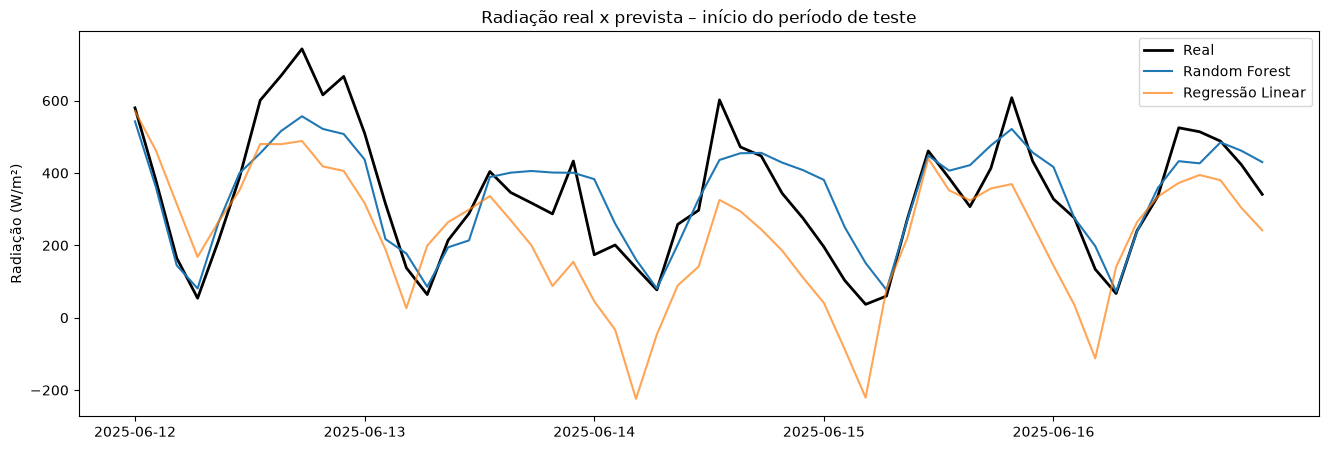

In [27]:
# Primeiros 5 dias do período de teste, para ver o comportamento ao longo do tempo
n = 55
datas_teste = meteo["data_hora"].iloc[corte:corte + n]

plt.figure(figsize=(16, 5))
plt.plot(range(n), y_r_teste.iloc[:n].values, label="Real", color="black", linewidth=2)
plt.plot(range(n), previsoes_regressao["Random Forest"][:n], label="Random Forest")
plt.plot(range(n), previsoes_regressao["Regressão Linear"][:n], label="Regressão Linear", alpha=0.7)
plt.xticks(range(0, n, 11), datas_teste.iloc[::11].str[:10])
plt.title("Radiação real x prevista – início do período de teste")
plt.ylabel("Radiação (W/m²)")
plt.legend()
plt.show()

### Interpretação – Tarefa 2

**Resultados:** o Random Forest foi o melhor nas três métricas: MAE de cerca de 67 W/m², MSE de cerca de 7300 (W/m²)² e R² de 0,84. Em seguida veio a Árvore de Decisão (MAE de 90 e R² de 0,69). A Regressão Linear ficou bem atrás (MAE de 145 e R² de 0,36).

**Papel da hora do dia:** a hora é o que mais explica a radiação, porque o sol sobe e desce todo dia. Mas a relação tem formato de sino e não de reta. A Regressão Linear só consegue usar a hora como "quanto mais tarde, mais (ou menos) radiação", então ela não consegue representar o pico ao meio-dia. Ela erra bastante em todas as horas, e mais ainda entre 10h e 14h, justamente onde fica o pico. As árvores conseguem dividir por faixas de hora (por exemplo, "antes das 9h" e "entre 11h e 14h"), por isso foram bem melhores.

**Erros:** mesmo o Random Forest erra em média 67 W/m². Os erros dele são menores no começo da manhã e no fim da tarde, quando a radiação é baixa, e maiores entre 10h e 14h, quando a radiação é alta e varia mais de um dia para o outro. A cobertura de nuvens é um valor da hora inteira e não diz exatamente se tinha nuvem na frente do sol, o que limita a precisão. Também lembramos que o teste é só a segunda quinzena de junho (12 a 30/06), então o modelo foi avaliado em poucas semanas de um período do ano.

**Radiação não é geração de energia:** o que previmos é a radiação que chega numa superfície horizontal (W/m²), estimada por modelo/reanálise e não medida num painel. Para chegar na energia gerada (kWh) ainda faltaria saber a área e a eficiência dos painéis, a inclinação e a direção deles, a perda por temperatura (painel quente rende menos), sujeira, sombra, perdas do inversor e da fiação, e se o sistema estava funcionando. Então uma boa previsão de radiação ajuda, mas não é a mesma coisa que prever quanto um sistema fotovoltaico vai produzir.

# Conclusões

**Tarefa 1 (classificação):** o Random Forest foi o melhor modelo (F1 macro de cerca de 0,98), com o KNN logo atrás e a Regressão Logística bem abaixo. O resultado alto vem muito do jeito como os dados foram coletados (amostra limitada por tipo, regiões concentradas e potência de 1 kW em várias solares), então não dá para dizer que potência e localização bastam para identificar a fonte de qualquer usina.

**Tarefa 2 (regressão):** o Random Forest também foi o melhor (R² de cerca de 0,84). A grande diferença para a Regressão Linear mostra que a relação entre hora do dia e radiação não é linear. O modelo estima radiação e não a energia gerada por um painel.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)